# Are American Robins Really a Sign of Spring? An Analysis of Complete eBird Checklists in North Carolina from 2021-2025

# Introduction

The American Robin is the most abundant bird in North America, with a population of about 370 million. You have likely seen them hopping through grass, looking for worms. Here is a photo of what they look like (taken by me): 

<img src="american-robin-image.JPG" width=50%>

In the United States, American Robins are considered to be the first signs of spring, despite being present year-round. This project uses data from eBird to see if there is a meaningful increase in their reporting at the beginning of spring, specifically in North Carolina. 

This analysis aims to answer: <b>are American Robins reported in a higher proportion of complete eBird checklists at the beginning of spring than other times of the year in North Carolina?</b>

Before we start, let's import the Python libraries that we need.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import warnings 
warnings.filterwarnings("ignore")

# Data Description
<a href="https://ebird.org/home">eBird</a> is a database run by the Cornell Lab of Ornithology that anyone can contribute to, by creating checklists to record birds that they see. They have a free and simple app that anyone can use, making it a popular tool among birders all around the globe, and therefore an abundant source of data. As of June 2025, eBird has passed <a href="https://ebird.org/news/ebird-passes-2-billion-bird-observations">2 billion bird observations</a>, so there is no shortage of data to analyze.

From <a href="https://science.ebird.org/en/use-ebird-data/download-ebird-data-products">the eBird website</a>, I downloaded the relevant datasets. I filtered my data to be checklists with American Robins in North Carolina from 2021-2025. I chose these years since the data from 2020 will likely be affected by the COVID-19 pandemic.

The download comes with two datasets: Sampling Event Data and EBD (eBird Basic Dataset). 
- The Sampling Event Data contains EVERY checklist in NC from 2021-2025 regardless if any American Robins were observed.
- The EBD contains ONLY checklists in NC from 2021-2025 where at least one American Robin was observed.

In other words, the EBD is a subset of the Sampling Event Data dataset.

These datasets are very large, so I kept only the relevant columns: 
- <b>Sampling Event Identifier</b>: the unique alphanumeric id for each "sampling event" i.e. checklist.
- <b>Observation Date</b>: the date the checklist was created.
- <b>All Species Reported</b>: whether the checklist is "complete" or not (0 means no, 1 means yes). A "complete" checklist means that the birder made an effort to find and report all birds around them to the best of their ability. In other words, they are not purposefully excluding any birds they saw off their list. This may occur if someone only logged a rare bird and omitted common birds like the American Robin. Or, birding was not someone's primary activity. Therefore, we want to filter to complete checklists only to reduce bias, which will do later.

Note: I only needed to keep the Sampling Event Identifier column for the EBD, because I will join these two datasets later.

In [2]:
# Sampling Event Data
df_all_checklists = pd.read_csv("data/ebd_US-NC_amerob_202101_202512_smp_relJun-2026_sampling.txt", 
                                sep="\t", 
                                usecols=["SAMPLING EVENT IDENTIFIER", "OBSERVATION DATE", "ALL SPECIES REPORTED"])

# EBD
df_ar_only_checklists = pd.read_csv("data/ebd_US-NC_amerob_202101_202512_smp_relJun-2026.txt", 
                                    sep="\t", 
                                    usecols=["SAMPLING EVENT IDENTIFIER"])

In [3]:
# preview the datasets
display(df_all_checklists.head())
display(df_ar_only_checklists.head())

,OBSERVATION DATE,SAMPLING EVENT IDENTIFIER,ALL SPECIES REPORTED
0,2021-01-01,S97910779,0
1,2021-01-01,S80813471,0
2,2021-01-01,S79515367,0
3,2021-01-01,S82780949,0
4,2021-01-01,S78407716,1


,SAMPLING EVENT IDENTIFIER
0,S78960242
1,S79477418
2,S79668245
3,S79849364
4,S79473462


In [4]:
print("Total number of checklists:", len(df_all_checklists))
print("Number of checklists with American Robins:", len(df_ar_only_checklists))

Total number of checklists: 1416862
Number of checklists with American Robins: 396766


In [5]:
print(df_all_checklists.dtypes)
print(df_ar_only_checklists.dtypes)

OBSERVATION DATE             object
SAMPLING EVENT IDENTIFIER    object
ALL SPECIES REPORTED          int64
dtype: object
SAMPLING EVENT IDENTIFIER    object
dtype: object


# Data Cleaning and Preparation

First, I checked for missing and duplicate values.

In [6]:
# check if there are any missing values
print("Number of missing values in df_all_checklists:", df_all_checklists.isna().sum().sum())
print("Number of missing values in df_ar_only_checklists:", df_ar_only_checklists.isna().sum().sum())

print("")

# check for duplicate values
print("Number of duplicate values in df_all_checklists:", df_all_checklists.duplicated().sum())
print("Number of duplicate values in df_ar_only_checklists:", df_ar_only_checklists.duplicated().sum())

Number of missing values in df_all_checklists: 0
Number of missing values in df_ar_only_checklists: 0

Number of duplicate values in df_all_checklists: 0
Number of duplicate values in df_ar_only_checklists: 242


Let's drop the duplicate values in df_ar_only_checklists.

In [7]:
df_ar_only_checklists = df_ar_only_checklists.drop_duplicates()
print("Number of duplicate values in df_ar_only_checklists:", df_ar_only_checklists.duplicated().sum())

Number of duplicate values in df_ar_only_checklists: 0


I want to filter to complete checklists only. First, let's check how ALL SPECIES REPORTED is encoded.

In [8]:
df_all_checklists["ALL SPECIES REPORTED"].value_counts()

1    1128849
0     288013
Name: ALL SPECIES REPORTED, dtype: int64

According to the <a href="data/eBird_Basic_Dataset_Metadata_v1.16.pdf">metadata</a>,
- 1 = True, completed checklist
- 0 = False, not completed checklist

So I want to filter checklists that have a value of 1 for ALL SPECIES REPORTED.

In [9]:
df_all_checklists = df_all_checklists.query("`ALL SPECIES REPORTED` == 1")

Let's check that only complete checklists remain:

In [10]:
print("Length of df_all_checklists:", len(df_all_checklists))
print("Sum of ALL SPECIES REPORTED values:", df_all_checklists["ALL SPECIES REPORTED"].sum())

Length of df_all_checklists: 1128849
Sum of ALL SPECIES REPORTED values: 1128849


They are equal, so only complete checklists remain. 

Now, let's create a new column called "robin_reported" in the df_ar_only_checklists. 
- 1 = checklist contains American Robin
- 0 = checklist does not contain robin

As a reminder, this dataframe ONLY contains observations with an American Robin, so every row will be assigned 1 for robin_reported.

In [11]:
df_ar_only_checklists["robin_reported"] = 1
print(df_ar_only_checklists.head())

  SAMPLING EVENT IDENTIFIER  robin_reported
0                 S78960242               1
1                 S79477418               1
2                 S79668245               1
3                 S79849364               1
4                 S79473462               1


Now let's merge the two dataframes into one called df_merged. After merging, the rows in df_all_checklists that were NOT in df_ar_only_checklists will be missing a number, so I will change them to be 0.

In [12]:
df_merged = pd.merge(left = df_all_checklists, right = df_ar_only_checklists, how = "left", on = "SAMPLING EVENT IDENTIFIER")
print(df_merged.head())

  OBSERVATION DATE SAMPLING EVENT IDENTIFIER  ALL SPECIES REPORTED  \
0       2021-01-01                 S78407716                     1   
1       2021-01-01                S296450589                     1   
2       2021-01-01                 S78450211                     1   
3       2021-01-01                 S78359157                     1   
4       2021-01-01                 S78393190                     1   

   robin_reported  
0             NaN  
1             NaN  
2             NaN  
3             NaN  
4             1.0  


In [13]:
df_merged["robin_reported"] = df_merged["robin_reported"].fillna(0)
print(df_merged.head())

  OBSERVATION DATE SAMPLING EVENT IDENTIFIER  ALL SPECIES REPORTED  \
0       2021-01-01                 S78407716                     1   
1       2021-01-01                S296450589                     1   
2       2021-01-01                 S78450211                     1   
3       2021-01-01                 S78359157                     1   
4       2021-01-01                 S78393190                     1   

   robin_reported  
0             0.0  
1             0.0  
2             0.0  
3             0.0  
4             1.0  


Now let's convert the OBSERVATION DATE values into datetime format so they will be more useful.

In [14]:
df_merged["OBSERVATION DATE"] = pd.to_datetime(df_merged["OBSERVATION DATE"])
print("Data Type:", df_merged["OBSERVATION DATE"].dtype)

Data Type: datetime64[ns]


I will create 2 new columns, the month and year of the observation. Since I converted the OBSERVATION DATE to datetime, I can use Series.dt.month to extract the month and year easily. Using this, January = 1, February = 2 ... November = 11, and December = 12.


In [15]:
df_merged["year"] = df_merged["OBSERVATION DATE"].dt.year
df_merged["month"] = df_merged["OBSERVATION DATE"].dt.month
print(df_merged.head())

  OBSERVATION DATE SAMPLING EVENT IDENTIFIER  ALL SPECIES REPORTED  \
0       2021-01-01                 S78407716                     1   
1       2021-01-01                S296450589                     1   
2       2021-01-01                 S78450211                     1   
3       2021-01-01                 S78359157                     1   
4       2021-01-01                 S78393190                     1   

   robin_reported  year  month  
0             0.0  2021      1  
1             0.0  2021      1  
2             0.0  2021      1  
3             0.0  2021      1  
4             1.0  2021      1  


Then, I will group by "year" and "month". I can treat ALL SPECIES REPORTED as the total number of checklists in that month, which is why I will sum the column up.

In [16]:
monthly_robins = df_merged.groupby(["year", "month"])["robin_reported", "ALL SPECIES REPORTED"].sum()
display(monthly_robins.head())

robin_reported  ALL SPECIES REPORTED
year month                                      
2021 1              5392.0                 18266
     2              7055.0                 20802
     3              7914.0                 17123
     4              8059.0                 20606
     5              8488.0                 24117

# Analysis

Now I can finally calculate the reporting rate, which is the number of checklists with a robin reported divided by the total number of checklists. The reporting rate is interpreted as "on X% of complete eBird checklists, the observer reported at least one American Robin".

In [17]:
# First rename ALL SPECIES REPORTED to total_checklists
monthly_robins = monthly_robins.rename(columns = {"ALL SPECIES REPORTED" : "total_checklists"})

# Reporting rate = robin_reported / total_checklists
monthly_robins["reporting_rate"] = monthly_robins["robin_reported"] / monthly_robins["total_checklists"]

# Convert to percentage and round to 2 decimal digits
monthly_robins["reporting_rate"] = (monthly_robins["reporting_rate"] * 100).round(2)

display(monthly_robins.head())

robin_reported  total_checklists  reporting_rate
year month                                                  
2021 1              5392.0             18266           29.52
     2              7055.0             20802           33.92
     3              7914.0             17123           46.22
     4              8059.0             20606           39.11
     5              8488.0             24117           35.20

Before plotting, I need to separate the year and month MultiIndex.

In [18]:
monthly_robins = monthly_robins.reset_index()
display(monthly_robins.head())

,year,month,robin_reported,total_checklists,reporting_rate
0,2021,1,5392.0,18266,29.52
1,2021,2,7055.0,20802,33.92
2,2021,3,7914.0,17123,46.22
3,2021,4,8059.0,20606,39.11
4,2021,5,8488.0,24117,35.20


# Results
Now we can finally plot the data! We will plot six lines total: a line for each of the years, and then one more line that is the average over 5 years.

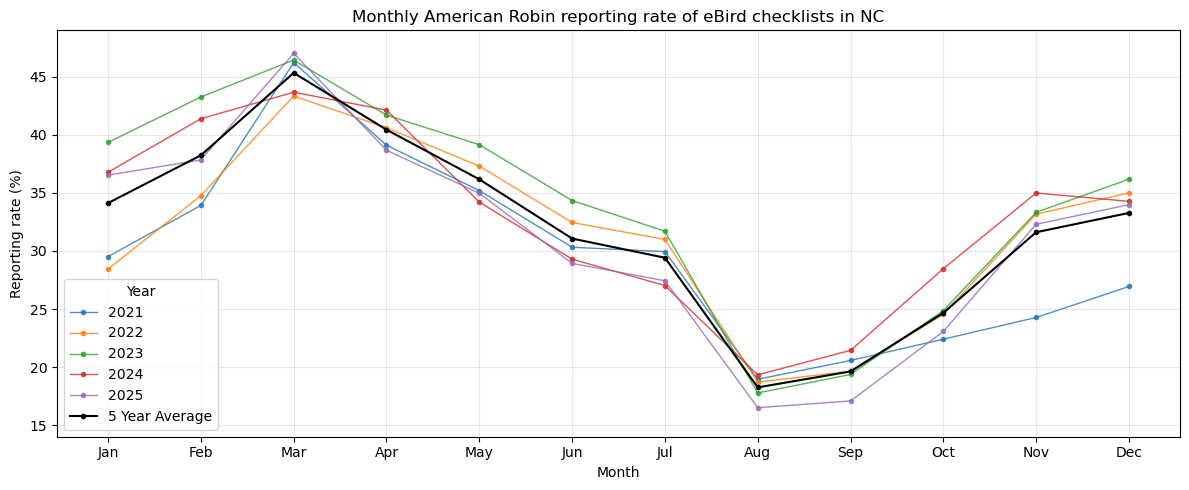

In [19]:
plt.figure(figsize=(12, 5))

# plot a line for each year
for year, year_data in monthly_robins.groupby("year"):
    year_data = year_data.sort_values("month")
    plt.plot("month", "reporting_rate", data=year_data, marker=".", linewidth=1, alpha=0.8, label=str(year))

# plot the average over 5 years
average = monthly_robins.groupby("month")["reporting_rate"].mean()
average.plot(label="5 Year Average", marker=".", linewidth=1.5, alpha=1, color="black")

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12], months)
plt.ylim(14, 49)
plt.xlabel("Month")
plt.ylabel("Reporting rate (%)")
plt.title("Monthly American Robin reporting rate of eBird checklists in NC")
plt.legend(title="Year")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Across all five years, American Robin reporting rates show a consistent pattern, with the highest reporting rates in March every single year. Reporting rates generally increase from January to March, and decrease in the spring and summer, before increasing again in the fall and winter. Interestingly, the reporting rate is lowest in August, dramatically decreasing from July.

To answer our original question, the first day of spring is March 1 or March 19-21, depending on the meteorological or astronomical definition. Thus, the results are consistent with the idea of American Robins as a sign of spring, with an average of about 45% of eBird checklists reporting at least one American Robin in March every year. Also, the peak in March does not come out of nowhere, as American Robins were frequently reported throughout the months leading up to March i.e. the winter. So the March peak appears to reflect a seasonal increase in observations rather than the sudden arrival of American Robins in the spring.

One cause of bias is that more people are likely to go birding in spring than other seasons in NC, because of spring migrations, hearing more birds singing, nice weather, or whatever the reason. More checklists means more sightings of robins, but doesn't necessarily mean there are more robins.

So could it be possible that the American Robin reporting rate was simply higher because more people submitted checklists? 

To answer this, let's plot the average American Robin reporting rate next to the average number of complete checklists. We will use the same data from 2021-2025 in North Carolina, and take the average over those 5 years.

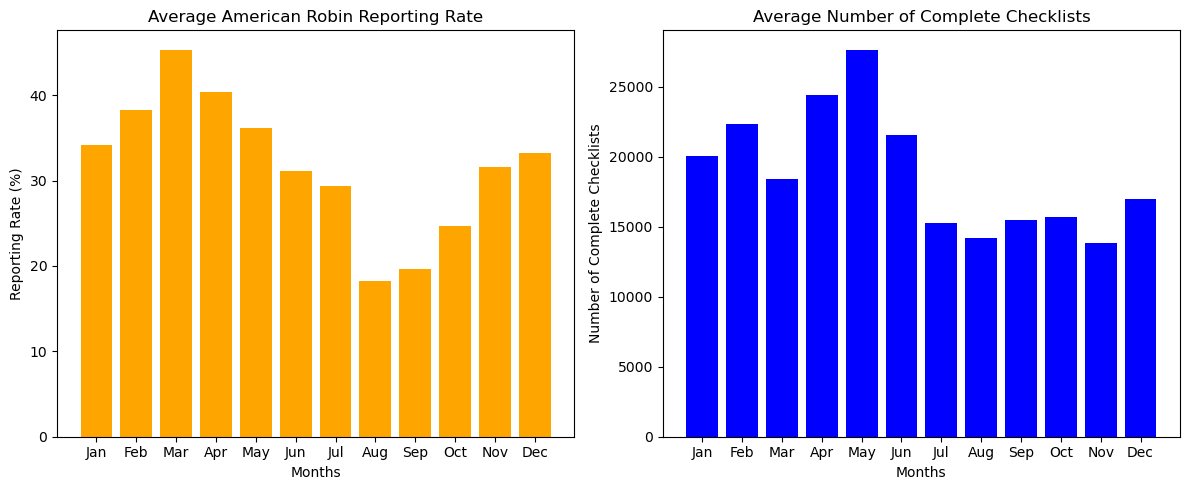

In [20]:
monthly_avg = monthly_robins.groupby(by="month", as_index=False)["reporting_rate", "total_checklists"].mean().round(2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# plot average reporting rate
ax1.bar(monthly_avg["month"], monthly_avg["reporting_rate"], color="orange")
ax1.set_title("Average American Robin Reporting Rate")
ax1.set_xlabel("Months")
ax1.set_ylabel("Reporting Rate (%)")
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(months)

# plot average number of checklists
ax2.bar(monthly_avg["month"], monthly_avg["total_checklists"], color="blue")
ax2.set_title("Average Number of Complete Checklists")
ax2.set_xlabel("Months")
ax2.set_ylabel("Number of Complete Checklists")
ax2.set_xticks(range(1,13))
ax2.set_xticklabels(months)

plt.tight_layout()
plt.show()

The two graphs show that the average reporting rate pattern doesn't just follow the number of checklists, i.e. the sampling size. In the left graph, March has the highest reporting rate, but in the right graph, March has fewer complete checklists than January, February, April, May, and June. In fact, May has the highest number of complete checklists, yet its American Robin reporting rate is declining from its peak in March.

Therefore, the March peak in American Robin reporting rates does not correspond to a peak in the number of complete checklists, suggesting that the pattern is not simply a result of increased eBird checklist submission during March.

Another example is how the number of complete checklists in August and November are similar. However, the American Robin reporting rate in August is clearly lower than in November. Again, this suggests that the reporting rate isn't following the same trends as the sample size.

# Conclusion
The results are consistent with the idea that American Robins are a "sign of spring" in North Carolina, as eBird users were most likely to report robins in March. 

This analysis has many limitations that are important to keep in mind. First, the reporting rate measures how frequently robins were observed on complete checklists, not the actual number of robins present. Therefore, this analysis cannot conclude that the American Robin population is highest in March or why they are more frequently detected at that time. eBird is also a citizen science project, not random samples. There is a lot of variation between checklists including location, time of day, the weather, and the specific habitats a person visits.

Further analysis calculate reporting rates for each week instead of each month. Another extension is comparing American Robins with other bird species that are also year-round residents, or conversely, migratory birds. Additionally, controlling for observation effort by filtering checklists with similar durations, distance traveled, and number of observers could help reduce more bias.